Starting optimization for non-sparse model...


ELBO: -204.63:  26%|██▌       | 26/100 [00:00<00:00, 122.78it/s]

ELBO: 166.37: 100%|██████████| 100/100 [00:01<00:00, 61.37it/s] 


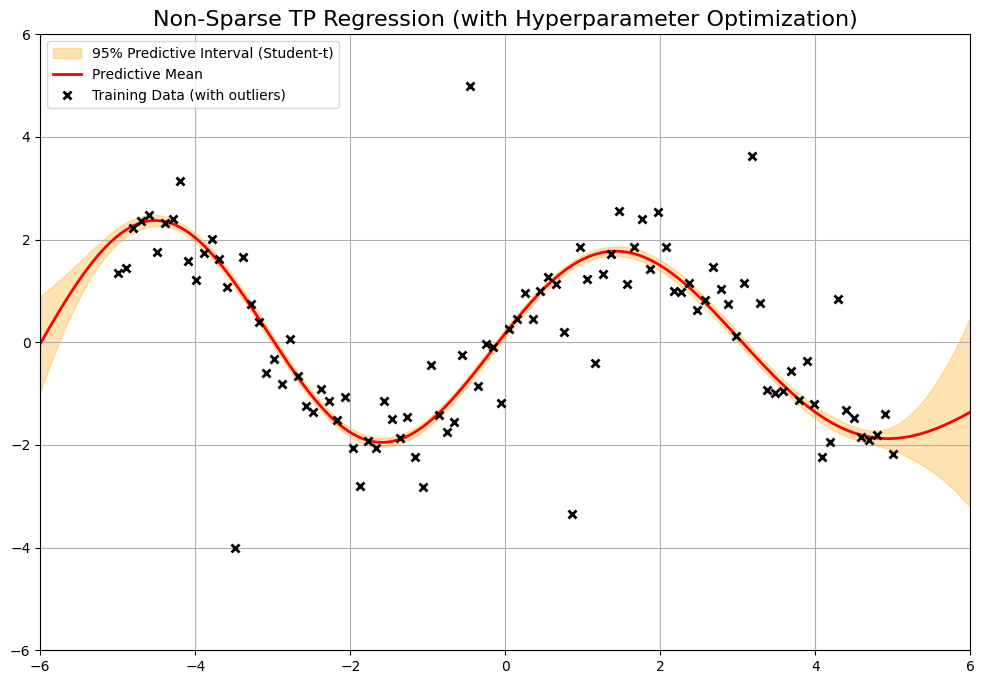

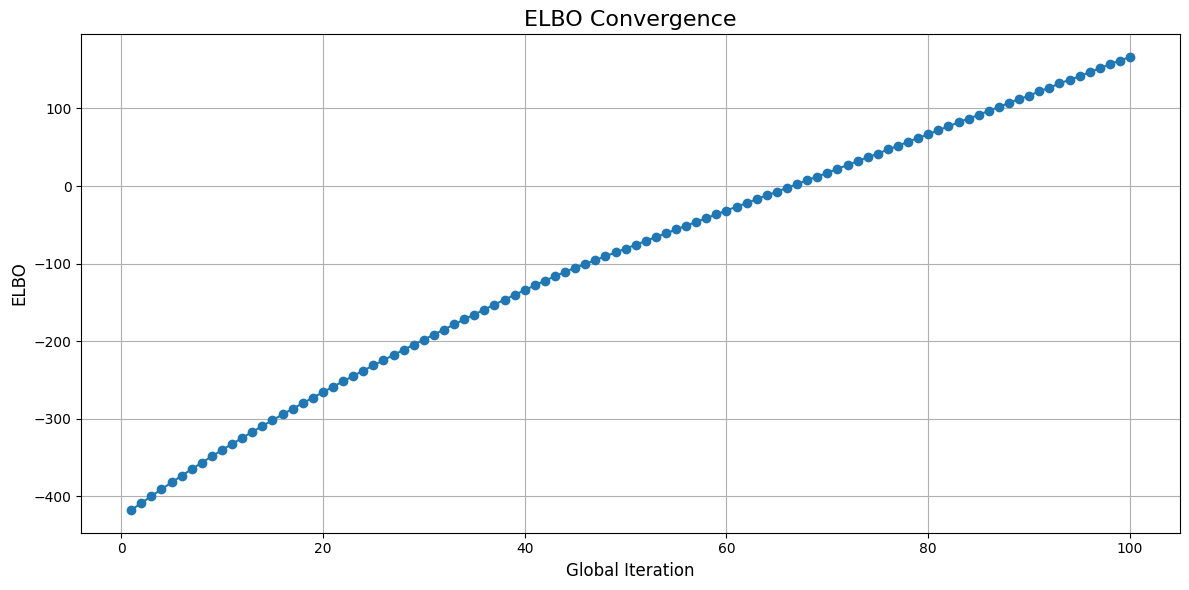

In [5]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        Returns the history of ELBO values.
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)
        elbo_history = [] # ADDED: To store ELBO values

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                # Kxx and Lxx must be recomputed inside the M-step loop
                # as hyperparameters are updated by the optimizer.
                Kxx_m_step = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_m_step = torch.linalg.cholesky(Kxx_m_step)
                neg_elbo = -self.calculate_elbo(Kxx_m_step, Lxx_m_step)
                neg_elbo.backward()
                optimizer.step()
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=100, max_iter_local=1, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


Starting optimization for non-sparse model...


ELBO: 49670.56: 100%|██████████| 10000/10000 [04:04<00:00, 40.89it/s]


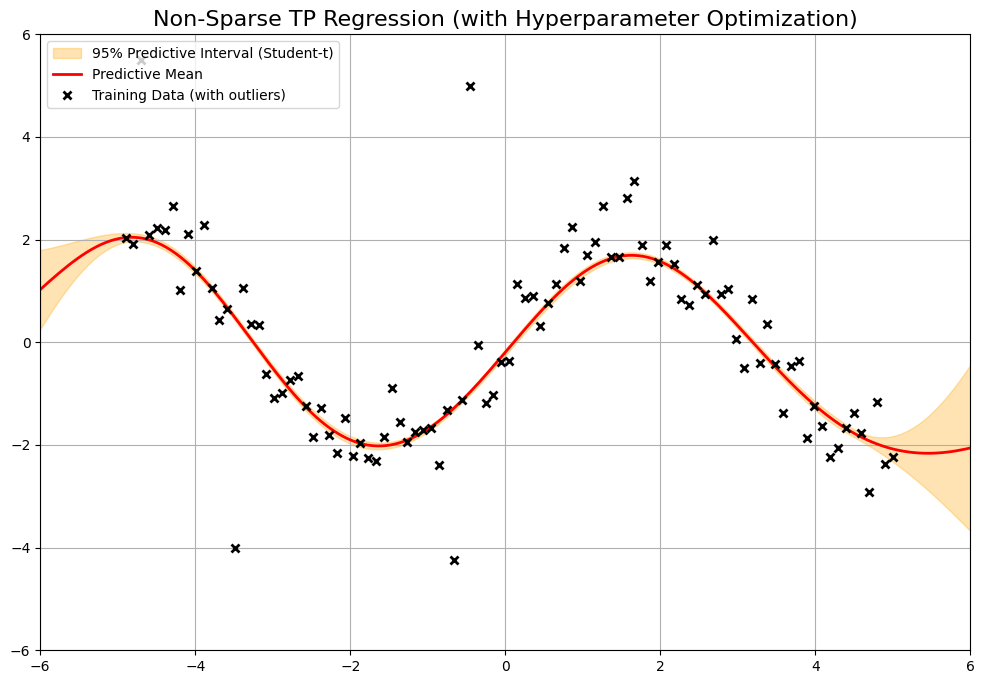

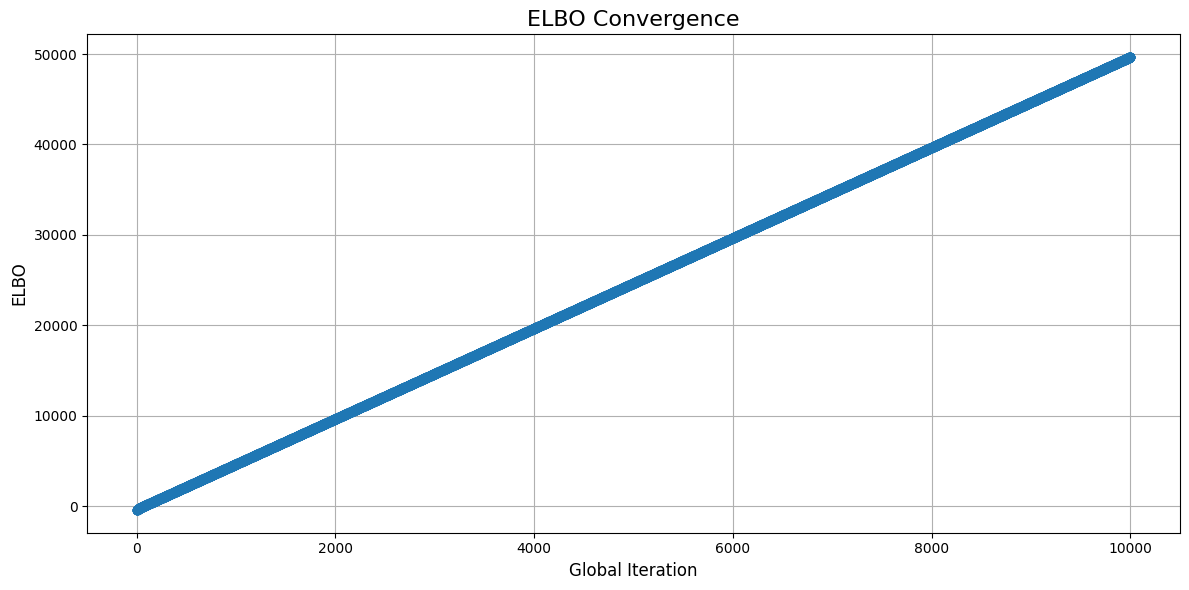

In [6]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=10000, max_iter_local=1, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


Starting optimization for non-sparse model...


ELBO: 49641.72: 100%|██████████| 1000/1000 [00:50<00:00, 19.70it/s]


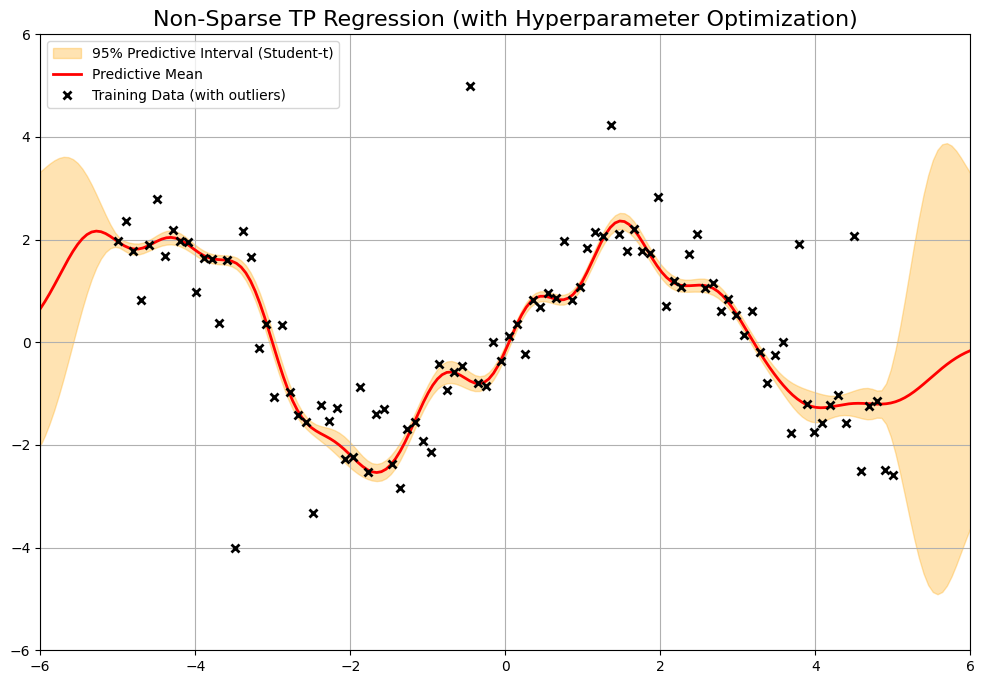

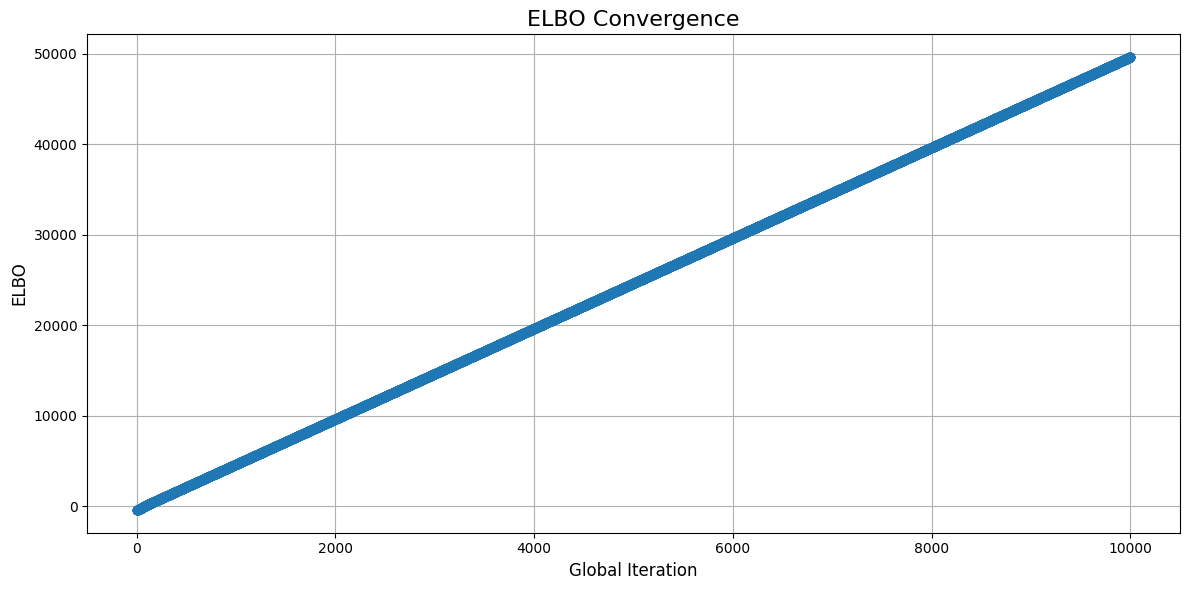

In [6]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=1000, max_iter_local=10, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


Starting optimization for non-sparse model...


ELBO: 4673.71: 100%|██████████| 100/100 [00:05<00:00, 16.91it/s]


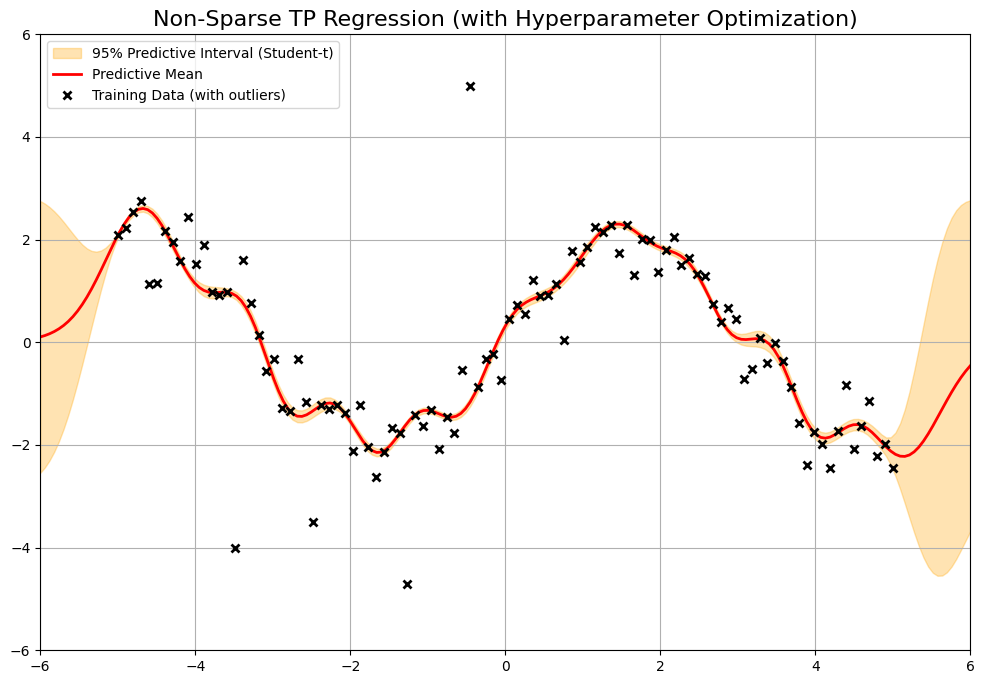

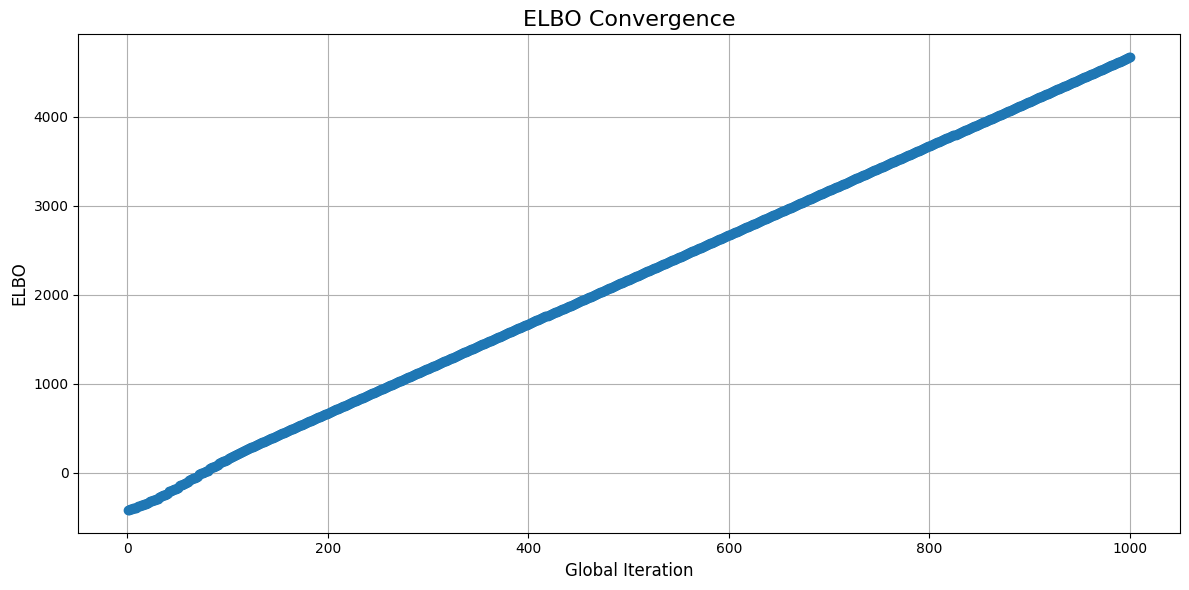

In [7]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=100, max_iter_local=10, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9)) # Add clamp for stability
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout() # Adjust layout to prevent labels overlapping

    plt.show()


# psd エラーだけはなんとか処理しないと実験が途中で止まってイライラしないといけなくなる．

# https://arxiv.org/pdf/1712.09913

Starting optimization for non-sparse model...


ELBO: -90.23:   0%|          | 0/500 [00:00<?, ?it/s] 

ELBO: 49786.11: 100%|██████████| 500/500 [00:36<00:00, 13.54it/s]


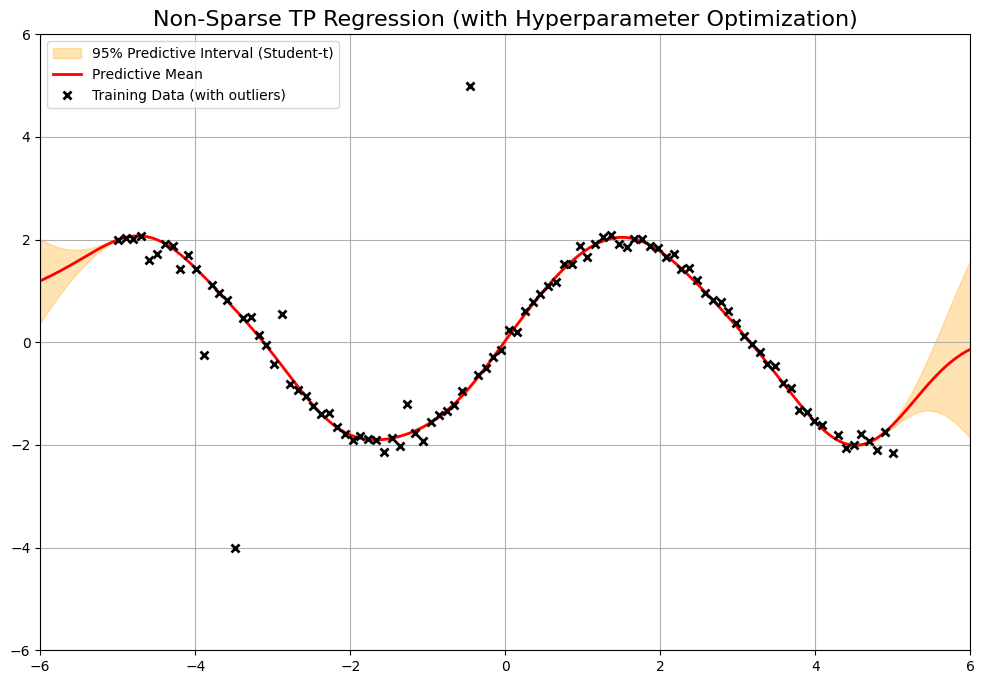

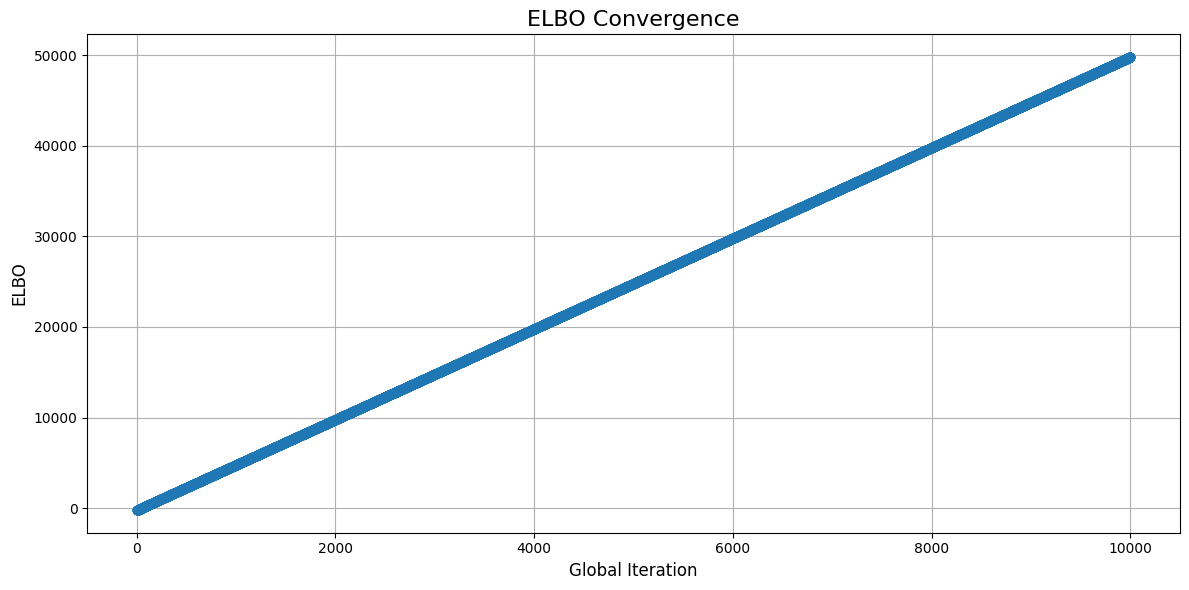


Generating ELBO landscape for 'log_kernel_lengthscale' and 'log_kernel_variance'...


Calculating Landscape: 100%|██████████| 625/625 [00:19<00:00, 32.13it/s]

Displaying interactive plot...


In [11]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
import copy # copyモジュールをインポート
import plotly.graph_objects as go # plotlyをインポート


import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This model works directly with the N x N kernel matrix and is suitable
    for smaller datasets due to its O(N^3) complexity.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter, so register as buffer
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        # These are updated via CAVI, not gradient descent, so they are not nn.Parameters.
        # q(f) = N(f | m_f, S_f), where S_f = L_f @ L_f.T
        self.m_f = torch.zeros(self.N, 1)
        self.L_f = torch.eye(self.N)

        # q(r) = Gamma(r | alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(lambda_i | alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)
        E_q_f = self.m_f

        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, Lxx):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T

        # E[f^T Kxx^-1 f] = Tr(Kxx^-1 S_f) + m_f^T Kxx^-1 m_f
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        self.alpha_r = nu_f / 2.0 + self.N / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

    def _update_q_f(self, Kxx, Lxx):
        """CAVI update for q(f)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # S_f^-1 = E[r] * Kxx^-1 + diag(E[lambda]/sigma^2)
        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = E_r * Kxx_inv + torch.diag(E_lambda.squeeze() / sigma_sq)
        
        # S_f = S_f_inv^-1
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N), L_f_inv, upper=False)[0]

        # m_f = S_f @ (diag(E[lambda]/sigma^2) @ y)
        temp_vec = (E_lambda / sigma_sq) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, Kxx, Lxx, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_f_old = self.m_f.clone()

            # CAVI updates
            self._update_q_lambda()
            self._update_q_r(Lxx)
            self._update_q_f(Kxx, Lxx)

            # Check for convergence
            change = torch.norm(self.m_f - m_f_old) / (torch.norm(m_f_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self, Kxx, Lxx):
        """Calculates the Evidence Lower Bound (ELBO) for the current model state."""
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        S_f = self.L_f @ self.L_f.T
        Var_q_f = S_f.diag().unsqueeze(1)

        # --- 1. Expected Log Likelihood ---
        E_q_f = self.m_f
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # log q(f)
        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_f))) - 0.5 * self.N
        
        # log q(r)
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        Kxx_inv_Sf = torch.cholesky_solve(S_f, Lxx)
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term

        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_f_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=100, max_iter_local=10, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by alternating between CAVI updates (E-step) and
        gradient-based hyperparameter updates (M-step).
        Returns the history of ELBO values.
        """
        print("Starting optimization for non-sparse model...")
        pbar = tqdm.trange(max_iter_global)
        elbo_history = [] # ADDED: To store ELBO values

        for i in pbar:
            # Recompute Kxx and its Cholesky factor in each loop as hyperparameters change
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # E-Step: Run CAVI to update variational parameters for q(f), q(r), q(lambda)
            with torch.no_grad():
                self._cavi_step(Kxx, Lxx, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters by maximizing the ELBO
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):
                optimizer.zero_grad()
                # Kxx and Lxx must be recomputed inside the M-step loop
                # as hyperparameters are updated by the optimizer.
                Kxx_m_step = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx_m_step = torch.linalg.cholesky(Kxx_m_step)
                neg_elbo = -self.calculate_elbo(Kxx_m_step, Lxx_m_step)
                neg_elbo.backward()
                optimizer.step()
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # Predictive Mean: E[f_*] = k(X_*, X) K(X,X)^-1 m_f
            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            # --- CORRECTED Predictive Variance Calculation ---
            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            # Term 1: Var[E[f_*|f]] = k_*x Kxx^-1 S_f Kxx^-1 k_x*
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()

            # Term 2: E[Var[f_*|f,r]] = E[r^-1] * (k_** - k_*x Kxx^-1 k_x*)
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            
            # The predictive distribution is Student-t
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()



# =============================================================================
# ADDED: Function to visualize the ELBO landscape
# =============================================================================
def visualize_elbo_landscape(trained_model, param1_name, param2_name,
                             range1_mult=2.0, range2_mult=2.0, resolution=20):
    """
    Visualizes the ELBO landscape with respect to two hyperparameters.
    
    Args:
        trained_model: The model object after running fit().
        param1_name (str): Name of the first hyperparameter (e.g., 'log_kernel_lengthscale').
        param2_name (str): Name of the second hyperparameter.
        range1_mult (float): Multiplier for the range of the first parameter around its optimal value.
        range2_mult (float): Multiplier for the range of the second parameter.
        resolution (int): The number of points to evaluate on each axis.
    """
    print(f"\nGenerating ELBO landscape for '{param1_name}' and '{param2_name}'...")
    
    # 1. Get the optimal hyperparameter values from the trained model (center of the plot)
    center_p1 = getattr(trained_model, param1_name).item()
    center_p2 = getattr(trained_model, param2_name).item()
    
    # 2. Define the grid for visualization
    p1_range = torch.linspace(center_p1 - range1_mult, center_p1 + range1_mult, resolution)
    p2_range = torch.linspace(center_p2 - range2_mult, center_p2 + range2_mult, resolution)
    elbo_grid = torch.zeros((resolution, resolution))

    # 3. Iterate over the grid, run CAVI, and compute ELBO for each point
    pbar = tqdm.tqdm(total=resolution*resolution, desc="Calculating Landscape")
    for i, p1_val in enumerate(p1_range):
        for j, p2_val in enumerate(p2_range):
            # Create a deep copy to not interfere with the original model
            temp_model = copy.deepcopy(trained_model)
            
            # Set the new hyperparameter values
            with torch.no_grad():
                getattr(temp_model, param1_name).fill_(p1_val)
                getattr(temp_model, param2_name).fill_(p2_val)
            
            # For these new hyperparameters, we need to find the optimal variational distribution
            # by running the E-step (CAVI)
            with torch.no_grad():
                Kxx = temp_model.kernel(temp_model.X, temp_model.X) + torch.eye(temp_model.N) * 1e-6
                Lxx = torch.linalg.cholesky(Kxx)
                temp_model._cavi_step(Kxx, Lxx, cavi_max_iter=50, cavi_tol=1e-6) # Run CAVI until convergence
            
            # Now calculate the ELBO with the converged variational parameters
            with torch.no_grad():
                elbo_val = temp_model.calculate_elbo(Kxx, Lxx)
                elbo_grid[i, j] = elbo_val.item()
            
            pbar.update(1)
    pbar.close()

    # 4. Create the 3D surface plot using Plotly
    fig = go.Figure(data=[go.Surface(
        z=elbo_grid.numpy().T, # Transpose for correct axis alignment
        x=torch.exp(p1_range).numpy(), # Convert log-scale back to original scale for plotting
        y=torch.exp(p2_range).numpy(),
        colorscale='Viridis',
        colorbar=dict(title='ELBO')
    )])

    fig.update_layout(
        title=f'ELBO Landscape vs. Kernel Hyperparameters',
        scene=dict(
            xaxis_title=f'{param1_name.replace("log_","")}',
            yaxis_title=f'{param2_name.replace("log_","")}',
            zaxis_title='ELBO'
        ),
        autosize=False,
        width=800, height=800,
        margin=dict(l=65, r=50, b=65, t=90)
    )
    
    print("Displaying interactive plot...")
    fig.show()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1.0
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=500, max_iter_local=20, lr=0.05, cavi_max_iter=20)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale
    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.title('Non-Sparse TP Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left'); plt.grid(True); plt.xlim(-6, 6); plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-')
    plt.title('ELBO Convergence', fontsize=16)
    plt.xlabel('Global Iteration', fontsize=12); plt.ylabel('ELBO', fontsize=12)
    plt.grid(True); plt.tight_layout()

    plt.show()

    # 7. ADDED: Call the landscape visualization function
    # Note: This can be slow for higher resolutions!
    visualize_elbo_landscape(
        trained_model=model,
        param1_name='log_kernel_lengthscale',
        param2_name='log_kernel_variance',
        resolution=25, # Use a moderate resolution
        range1_mult=1.0,
        range2_mult=1.0
    )